# Homework: Image Captioning using GANs Architecture  
## MITE: 19
## Subject: ILLM
## Shift: Evening
## Year: 2
## Semester: 1
## Student Name: Seng Phirum

**Dataset:** COCO Captioning 2015 task page: https://cocodataset.org/#captions-2015

This notebook is intentionally small and easy to explain. It uses a tiny subset of COCO images so it can run on a normal laptop or Google Colab.

## Idea

1. **Generator:** a CNN encoder extracts image features, then an LSTM decoder generates a caption.
2. **Discriminator:** receives the image feature and a caption, then predicts whether the caption is real COCO text or generated text.
3. **GAN training:** the generator learns with normal caption loss plus a small adversarial loss so generated captions look more like real captions.
4. **Evaluation:** BLEU-1, BLEU-2, BLEU-4 and example predicted captions.

> Note: For fast homework training, the notebook downloads the official COCO 2014 train/validation caption annotations and only a small number of validation images. The 2015 captioning challenge is based on COCO captioning data; using this small subset keeps the demo understandable.

In [1]:
# If running in Google Colab, turn on GPU:
# Runtime -> Change runtime type -> GPU

import importlib.util
import subprocess
import sys

required = {
    "torch": "torch",
    "torchvision": "torchvision",
    "PIL": "pillow",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
}
missing = [pip_name for module_name, pip_name in required.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are available.")

Installing missing packages: ['pandas']


In [2]:
import json
import math
import os
import random
import re
import urllib.request
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


c:\Users\PhirumSeng\.pyenv\pyenv-win\versions\3.13.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

Change `N_IMAGES` if you want faster or better results.

- `80` images: very fast testing, weak captions
- `300` images: good for homework demo
- `1000+` images: better results, longer training

In [3]:
DATA_DIR = Path("data/coco_caption_gan")
IMAGE_DIR = DATA_DIR / "val2014_images"
ANNOTATION_ZIP = DATA_DIR / "annotations_trainval2014.zip"
ANNOTATION_JSON = DATA_DIR / "annotations" / "captions_val2014.json"
RESULTS_DIR = Path("results")

ANNOTATION_URL = "https://images.cocodataset.org/annotations/annotations_trainval2014.zip"

N_IMAGES = 300
VAL_SPLIT = 0.20
MAX_CAPTIONS_PER_IMAGE = 5
MAX_LEN = 16
MIN_WORD_FREQ = 2

BATCH_SIZE = 16
EMBED_DIM = 128
HIDDEN_DIM = 256
IMAGE_FEATURE_DIM = 256

SUPERVISED_EPOCHS = 2
GAN_EPOCHS = 1
LEARNING_RATE = 1e-3
ADV_WEIGHT = 0.20

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 2. Download a Small COCO Subset

The full COCO image folder is several GB. To keep this simple, we download the official caption annotation file and then download only `N_IMAGES` individual validation images.

In [4]:
def download_file(url, output_path):
    output_path = Path(output_path)
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Already downloaded: {output_path}")
        return

    output_path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = output_path.with_suffix(output_path.suffix + ".part")
    if temp_path.exists():
        temp_path.unlink()

    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    print(f"Downloading {url}")
    try:
        with urllib.request.urlopen(request, timeout=120) as response:
            total = int(response.headers.get("Content-Length", 0))
            with open(temp_path, "wb") as file, tqdm(total=total, unit="B", unit_scale=True) as progress:
                while True:
                    chunk = response.read(1024 * 1024)
                    if not chunk:
                        break
                    file.write(chunk)
                    progress.update(len(chunk))
        temp_path.replace(output_path)
    except Exception:
        if temp_path.exists():
            temp_path.unlink()
        raise


def extract_caption_annotations():
    if ANNOTATION_JSON.exists():
        print("Annotation JSON already extracted.")
        return

    try:
        download_file(ANNOTATION_URL, ANNOTATION_ZIP)
    except Exception as error:
        print("HTTPS annotation download failed. Trying HTTP fallback.")
        print("Reason:", error)
        download_file(ANNOTATION_URL.replace("https://", "http://"), ANNOTATION_ZIP)

    print("Extracting captions_val2014.json ...")
    with zipfile.ZipFile(ANNOTATION_ZIP, "r") as zip_ref:
        zip_ref.extract("annotations/captions_val2014.json", DATA_DIR)


extract_caption_annotations()

with open(ANNOTATION_JSON, "r", encoding="utf-8") as file:
    coco = json.load(file)

captions_by_image = defaultdict(list)
for ann in coco["annotations"]:
    captions_by_image[ann["image_id"]].append(ann["caption"])

images_with_captions = [img for img in coco["images"] if img["id"] in captions_by_image]
random.Random(SEED).shuffle(images_with_captions)
selected_images = images_with_captions[:N_IMAGES]

print("Images in COCO val captions:", len(images_with_captions))
print("Selected images:", len(selected_images))
print("Example file:", selected_images[0]["file_name"])

HTTPS annotation download failed. Trying HTTP fallback.
Reason: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'images.cocodataset.org'. (_ssl.c:1032)>


100%|██████████| 253M/253M [06:22<00:00, 660kB/s]  


Extracting captions_val2014.json ...
Images in COCO val captions: 40504
Selected images: 300
Example file: COCO_val2014_000000015055.jpg


In [5]:
def download_coco_image(image_record):
    file_name = image_record["file_name"]
    output_path = IMAGE_DIR / file_name
    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    url = image_record.get("coco_url") or f"https://images.cocodataset.org/val2014/{file_name}"
    url = url.replace("http://", "https://")

    try:
        download_file(url, output_path)
    except Exception:
        # Some environments block HTTPS for older COCO links. Try HTTP as fallback.
        fallback_url = url.replace("https://", "http://")
        download_file(fallback_url, output_path)
    return output_path


for image_record in tqdm(selected_images, desc="Downloading selected images"):
    download_coco_image(image_record)

print("Downloaded image files:", len(list(IMAGE_DIR.glob("*.jpg"))))

100%|██████████| 260k/260k [00:01<00:00, 152kB/s]

100%|██████████| 121k/121k [00:00<00:00, 155kB/s]

100%|██████████| 64.7k/64.7k [00:00<00:00, 123kB/s]

100%|██████████| 66.2k/66.2k [00:00<00:00, 124kB/s]

100%|██████████| 135k/135k [00:00<00:00, 196kB/s]

...

100%|██████████| 231k/231k [00:01<00:00, 222kB/s]

100%|██████████| 136k/136k [00:00<00:00, 174kB/s]

100%|██████████| 242k/242k [00:01<00:00, 226kB/s]

100%|██████████| 183k/183k [00:00<00:00, 238kB/s]

Downloaded image files: 300


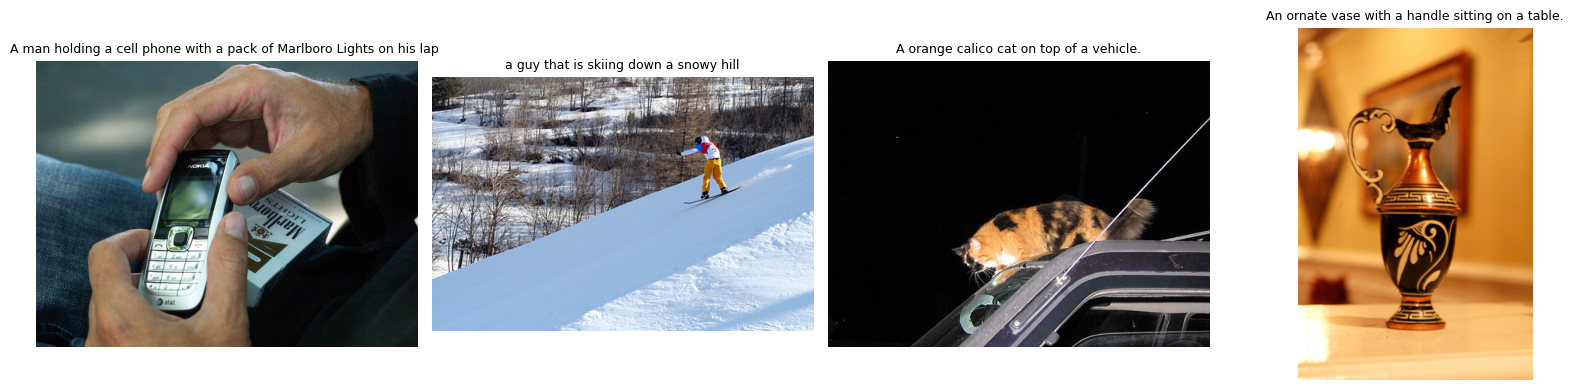

In [6]:
# Show a few training examples.
preview_count = min(4, len(selected_images))
fig, axes = plt.subplots(1, preview_count, figsize=(4 * preview_count, 4))
if preview_count == 1:
    axes = [axes]

for ax, image_record in zip(axes, selected_images[:preview_count]):
    image = Image.open(IMAGE_DIR / image_record["file_name"]).convert("RGB")
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(captions_by_image[image_record["id"]][0][:80], fontsize=9)

plt.tight_layout()
plt.show()

## 3. Text Preprocessing and Vocabulary

Captions are converted into tokens. We add four special tokens:

- `<pad>` for padding short captions
- `<bos>` for beginning of sentence
- `<eos>` for end of sentence
- `<unk>` for rare words

In [7]:
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())


split_index = int(len(selected_images) * (1 - VAL_SPLIT))
train_images = selected_images[:split_index]
val_images = selected_images[split_index:]

train_samples = []
for image_record in train_images:
    image_id = image_record["id"]
    for caption in captions_by_image[image_id][:MAX_CAPTIONS_PER_IMAGE]:
        train_samples.append({"file_name": image_record["file_name"], "caption": caption, "image_id": image_id})

word_counter = Counter()
for sample in train_samples:
    word_counter.update(tokenize(sample["caption"]))

special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]
words = [word for word, count in word_counter.most_common() if count >= MIN_WORD_FREQ]
itos = special_tokens + words
stoi = {word: index for index, word in enumerate(itos)}

PAD_ID = stoi["<pad>"]
BOS_ID = stoi["<bos>"]
EOS_ID = stoi["<eos>"]
UNK_ID = stoi["<unk>"]
VOCAB_SIZE = len(itos)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Training caption samples:", len(train_samples))
print("Vocabulary size:", VOCAB_SIZE)

Training images: 240
Validation images: 60
Training caption samples: 1200
Vocabulary size: 832


In [8]:
def encode_caption(caption, max_len=MAX_LEN):
    tokens = tokenize(caption)[: max_len - 2]
    ids = [BOS_ID] + [stoi.get(token, UNK_ID) for token in tokens] + [EOS_ID]
    ids += [PAD_ID] * (max_len - len(ids))
    return torch.tensor(ids, dtype=torch.long)


def decode_ids(ids):
    words = []
    for token_id in ids:
        token_id = int(token_id)
        if token_id in (PAD_ID, BOS_ID):
            continue
        if token_id == EOS_ID:
            break
        words.append(itos[token_id] if token_id < len(itos) else "<unk>")
    return " ".join(words)


print("Original:", train_samples[0]["caption"])
encoded = encode_caption(train_samples[0]["caption"])
print("Encoded:", encoded.tolist())
print("Decoded:", decode_ids(encoded))

Original: A man holding a cell phone with a pack of Marlboro Lights on his lap 
Encoded: [1, 4, 12, 27, 4, 104, 76, 9, 4, 3, 6, 584, 251, 7, 34, 2]
Decoded: a man holding a cell phone with a <unk> of marlboro lights on his


## 4. PyTorch Dataset

In [9]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class CocoCaptionDataset(Dataset):
    def __init__(self, samples, image_dir, transform):
        self.samples = samples
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image = Image.open(self.image_dir / sample["file_name"]).convert("RGB")
        image = self.transform(image)
        caption_ids = encode_caption(sample["caption"])
        return image, caption_ids


train_dataset = CocoCaptionDataset(train_samples, IMAGE_DIR, image_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

batch_images, batch_captions = next(iter(train_loader))
print("Image batch shape:", batch_images.shape)
print("Caption batch shape:", batch_captions.shape)

Image batch shape: torch.Size([16, 3, 224, 224])
Caption batch shape: torch.Size([16, 16])


## 5. Model Architecture

### Generator

`Image -> MobileNetV2 CNN encoder -> image feature -> LSTM decoder -> caption words`

### Discriminator

`Image feature + caption -> LSTM text encoder -> real/fake score`

The discriminator is conditioned on the image, so it should learn whether a caption matches the image and looks like a real COCO caption.

In [10]:
class CNNEncoder(nn.Module):
    def __init__(self, output_dim=IMAGE_FEATURE_DIM):
        super().__init__()
        try:
            weights = models.MobileNet_V2_Weights.DEFAULT
            base_model = models.mobilenet_v2(weights=weights)
        except Exception:
            base_model = models.mobilenet_v2(pretrained=True)

        self.features = base_model.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj = nn.Sequential(
            nn.Linear(base_model.last_channel, output_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        for parameter in self.features.parameters():
            parameter.requires_grad = False

    def train(self, mode=True):
        super().train(mode)
        self.features.eval()
        return self

    def forward(self, images):
        with torch.no_grad():
            x = self.features(images)
            x = self.pool(x).flatten(1)
        return self.proj(x)


class CaptionGenerator(nn.Module):
    def __init__(self, vocab_size, image_dim=IMAGE_FEATURE_DIM, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.init_h = nn.Linear(image_dim, hidden_dim)
        self.init_c = nn.Linear(image_dim, hidden_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.output = nn.Linear(hidden_dim, vocab_size)

    def initial_state(self, image_features):
        h0 = torch.tanh(self.init_h(image_features)).unsqueeze(0)
        c0 = torch.tanh(self.init_c(image_features)).unsqueeze(0)
        return h0, c0

    def forward(self, image_features, input_tokens):
        embeddings = self.embedding(input_tokens)
        outputs, _ = self.lstm(embeddings, self.initial_state(image_features))
        logits = self.output(outputs)
        return logits

    @torch.no_grad()
    def generate(self, image_features, max_len=MAX_LEN):
        self.eval()
        current = torch.tensor([[BOS_ID]], device=image_features.device)
        state = self.initial_state(image_features)
        generated_ids = []

        for _ in range(max_len - 1):
            embedding = self.embedding(current)
            output, state = self.lstm(embedding, state)
            logits = self.output(output[:, -1, :])
            next_id = int(torch.argmax(logits, dim=-1).item())

            if next_id == EOS_ID:
                break
            generated_ids.append(next_id)
            current = torch.tensor([[next_id]], device=image_features.device)

        return generated_ids


class CaptionDiscriminator(nn.Module):
    def __init__(self, vocab_size, image_dim=IMAGE_FEATURE_DIM, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.text_lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.image_proj = nn.Linear(image_dim, hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
        )

    def forward_tokens(self, image_features, token_ids):
        embeddings = self.embedding(token_ids)
        return self.forward_embeddings(image_features, embeddings)

    def forward_soft(self, image_features, soft_token_probs):
        # Differentiable caption representation: probability distribution x embedding matrix.
        embeddings = torch.matmul(soft_token_probs, self.embedding.weight)
        return self.forward_embeddings(image_features, embeddings)

    def forward_embeddings(self, image_features, embeddings):
        _, (hidden, _) = self.text_lstm(embeddings)
        text_feature = hidden[-1]
        image_feature = torch.tanh(self.image_proj(image_features))
        combined = torch.cat([image_feature, text_feature], dim=1)
        return self.classifier(combined).squeeze(1)


encoder = CNNEncoder().to(DEVICE)
generator = CaptionGenerator(VOCAB_SIZE).to(DEVICE)
discriminator = CaptionDiscriminator(VOCAB_SIZE).to(DEVICE)

print("Generator parameters:", sum(p.numel() for p in generator.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in discriminator.parameters()))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\PhirumSeng/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:02<00:00, 6.12MB/s]


Generator parameters: 847168
Discriminator parameters: 699137


## 6. Training Step 1: Supervised Caption Training

First, train the generator like a normal image captioning model. This makes the GAN training stable.

In [11]:
caption_loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer_g = torch.optim.Adam(
    list(encoder.proj.parameters()) + list(generator.parameters()),
    lr=LEARNING_RATE,
)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE)


def supervised_train_one_epoch(epoch):
    encoder.train()
    generator.train()
    total_loss = 0.0

    progress = tqdm(train_loader, desc=f"Supervised epoch {epoch}")
    for images, captions in progress:
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)

        input_tokens = captions[:, :-1]
        target_tokens = captions[:, 1:]

        image_features = encoder(images)
        logits = generator(image_features, input_tokens)
        loss = caption_loss_fn(logits.reshape(-1, VOCAB_SIZE), target_tokens.reshape(-1))

        optimizer_g.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        optimizer_g.step()

        total_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.3f}")

    return total_loss / max(1, len(train_loader))


supervised_history = []
for epoch in range(1, SUPERVISED_EPOCHS + 1):
    avg_loss = supervised_train_one_epoch(epoch)
    supervised_history.append(avg_loss)
    print(f"Epoch {epoch}: supervised generator loss = {avg_loss:.4f}")

Supervised epoch 1: 100%|██████████| 75/75 [00:28<00:00,  2.60it/s, loss=4.408]


Epoch 1: supervised generator loss = 4.8936


Supervised epoch 2: 100%|██████████| 75/75 [00:27<00:00,  2.74it/s, loss=4.135]

Epoch 2: supervised generator loss = 4.0989


## 7. Training Step 2: Simple GAN Fine-Tuning

Now we add the discriminator.

- **Real caption:** COCO caption from the dataset
- **Fake caption:** generator output distribution
- **Discriminator loss:** classify real as 1 and fake as 0
- **Generator loss:** normal caption loss + adversarial loss trying to make fake captions look real

Because words are discrete, this notebook uses a simple differentiable trick: the generator sends **soft word probabilities** to the discriminator instead of hard sampled words.

In [12]:
bce_loss_fn = nn.BCEWithLogitsLoss()


def set_requires_grad(module, value):
    for parameter in module.parameters():
        parameter.requires_grad = value


def gan_train_one_epoch(epoch):
    encoder.train()
    generator.train()
    discriminator.train()

    total_d_loss = 0.0
    total_g_loss = 0.0

    progress = tqdm(train_loader, desc=f"GAN epoch {epoch}")
    for images, captions in progress:
        images = images.to(DEVICE)
        captions = captions.to(DEVICE)
        input_tokens = captions[:, :-1]
        real_tokens = captions[:, 1:]

        # 1. Train discriminator.
        set_requires_grad(discriminator, True)
        optimizer_d.zero_grad()

        with torch.no_grad():
            image_features_d = encoder(images)
            fake_logits_d = generator(image_features_d, input_tokens)
            fake_probs_d = F.softmax(fake_logits_d, dim=-1)

        real_scores = discriminator.forward_tokens(image_features_d.detach(), real_tokens)
        fake_scores = discriminator.forward_soft(image_features_d.detach(), fake_probs_d.detach())

        real_labels = torch.ones_like(real_scores)
        fake_labels = torch.zeros_like(fake_scores)
        d_loss = 0.5 * (
            bce_loss_fn(real_scores, real_labels) +
            bce_loss_fn(fake_scores, fake_labels)
        )
        d_loss.backward()
        optimizer_d.step()

        # 2. Train generator to create captions that fool discriminator.
        set_requires_grad(discriminator, False)
        optimizer_g.zero_grad()

        image_features_g = encoder(images)
        fake_logits_g = generator(image_features_g, input_tokens)
        supervised_loss = caption_loss_fn(fake_logits_g.reshape(-1, VOCAB_SIZE), real_tokens.reshape(-1))

        fake_probs_g = F.softmax(fake_logits_g, dim=-1)
        fool_scores = discriminator.forward_soft(image_features_g, fake_probs_g)
        adversarial_loss = bce_loss_fn(fool_scores, torch.ones_like(fool_scores))

        g_loss = supervised_loss + ADV_WEIGHT * adversarial_loss
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        optimizer_g.step()
        set_requires_grad(discriminator, True)

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()
        progress.set_postfix(d_loss=f"{d_loss.item():.3f}", g_loss=f"{g_loss.item():.3f}")

    return total_d_loss / max(1, len(train_loader)), total_g_loss / max(1, len(train_loader))


gan_history = []
for epoch in range(1, GAN_EPOCHS + 1):
    avg_d_loss, avg_g_loss = gan_train_one_epoch(epoch)
    gan_history.append({"epoch": epoch, "d_loss": avg_d_loss, "g_loss": avg_g_loss})
    print(f"Epoch {epoch}: discriminator loss = {avg_d_loss:.4f}, generator loss = {avg_g_loss:.4f}")

GAN epoch 1: 100%|██████████| 75/75 [01:07<00:00,  1.11it/s, d_loss=0.418, g_loss=3.967]

Epoch 1: discriminator loss = 0.5333, generator loss = 4.5096


## 8. Evaluation Results

This section generates captions for validation images and reports BLEU scores.

BLEU compares generated captions with the five human COCO captions for each image. For a tiny model and a tiny dataset, the scores will not be high. The goal here is to show a clear working GAN-style captioning pipeline.

In [13]:
def load_image_tensor(file_name):
    image = Image.open(IMAGE_DIR / file_name).convert("RGB")
    return image_transform(image).unsqueeze(0).to(DEVICE)


def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(max(0, len(tokens) - n + 1)))


def corpus_bleu_score(all_references, all_hypotheses, max_n=4, smooth=1.0):
    clipped_counts = [0.0] * max_n
    total_counts = [0.0] * max_n
    hypothesis_length = 0
    reference_length = 0

    for references, hypothesis in zip(all_references, all_hypotheses):
        hypothesis_length += len(hypothesis)
        reference_lengths = [len(reference) for reference in references]
        if reference_lengths:
            reference_length += min(reference_lengths, key=lambda length: (abs(length - len(hypothesis)), length))

        for n in range(1, max_n + 1):
            hyp_counts = ngram_counts(hypothesis, n)
            total_counts[n - 1] += max(1, sum(hyp_counts.values()))

            max_ref_counts = Counter()
            for reference in references:
                max_ref_counts |= ngram_counts(reference, n)

            clipped_counts[n - 1] += sum(
                min(count, max_ref_counts[ngram])
                for ngram, count in hyp_counts.items()
            )

    precisions = [
        (clipped_counts[i] + smooth) / (total_counts[i] + smooth)
        for i in range(max_n)
    ]
    brevity_penalty = 1.0 if hypothesis_length > reference_length else math.exp(1 - reference_length / max(1, hypothesis_length))
    return brevity_penalty * math.exp(sum(math.log(p) for p in precisions) / max_n)


encoder.eval()
generator.eval()

rows = []
all_references = []
all_hypotheses = []

for image_record in tqdm(val_images, desc="Evaluating"):
    image_tensor = load_image_tensor(image_record["file_name"])
    image_features = encoder(image_tensor)
    generated_ids = generator.generate(image_features)
    prediction = decode_ids(generated_ids)
    prediction_tokens = tokenize(prediction)

    references = [tokenize(caption)[:MAX_LEN - 2] for caption in captions_by_image[image_record["id"]]]

    all_hypotheses.append(prediction_tokens)
    all_references.append(references)
    rows.append({
        "image_id": image_record["id"],
        "file_name": image_record["file_name"],
        "prediction": prediction,
        "reference_1": captions_by_image[image_record["id"]][0],
    })

metrics = {
    "num_train_images": len(train_images),
    "num_val_images": len(val_images),
    "vocab_size": VOCAB_SIZE,
    "bleu_1": corpus_bleu_score(all_references, all_hypotheses, max_n=1),
    "bleu_2": corpus_bleu_score(all_references, all_hypotheses, max_n=2),
    "bleu_4": corpus_bleu_score(all_references, all_hypotheses, max_n=4),
}

results_df = pd.DataFrame(rows)
print(json.dumps(metrics, indent=2))
display(results_df.head(10))

Evaluating: 100%|██████████| 60/60 [00:04<00:00, 12.41it/s]

{
  "num_train_images": 240,
  "num_val_images": 60,
  "vocab_size": 832,
  "bleu_1": 0.374610269190047,
  "bleu_2": 0.1969173020603498,
  "bleu_4": 0.039127689476337255
}


,image_id,file_name,prediction,reference_1
0,397278,COCO_val2014_000000397278.jpg,a man is on a <unk>,A yellow sign sitting on the side of a road.
1,37875,COCO_val2014_000000037875.jpg,a man is on a <unk>,A boy holding an umbrella standing on a street.
2,437898,COCO_val2014_000000437898.jpg,a man is on a <unk>,A medium sized home kitchen with wood cabinets.
3,24144,COCO_val2014_000000024144.jpg,a man is on a <unk>,A pizza sitting on top of a pizza box covered ...
4,271206,COCO_val2014_000000271206.jpg,a man is on a <unk>,A white sink sitting underneath a round mirror.
5,82835,COCO_val2014_000000082835.jpg,a man is on a <unk>,A man and dog that is sitting in a ski lift.
6,103030,COCO_val2014_000000103030.jpg,a man is on a <unk>,Two tables filled with food under a red tent.
7,560332,COCO_val2014_000000560332.jpg,a man is on a <unk>,A suitcase sitting on a bench in front of a bed.
8,371782,COCO_val2014_000000371782.jpg,a man is on a <unk>,A teddy bear holding up miniature replica pizz...
9,409239,COCO_val2014_000000409239.jpg,a man is on a <unk>,An uneaten traditional pizza served at a table.


In [14]:
# Save evaluation results for submission.
with open(RESULTS_DIR / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

results_df.to_csv(RESULTS_DIR / "evaluation_results.csv", index=False)

torch.save({
    "encoder": encoder.state_dict(),
    "generator": generator.state_dict(),
    "discriminator": discriminator.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "config": {
        "n_images": N_IMAGES,
        "max_len": MAX_LEN,
        "supervised_epochs": SUPERVISED_EPOCHS,
        "gan_epochs": GAN_EPOCHS,
        "adv_weight": ADV_WEIGHT,
    },
}, RESULTS_DIR / "image_captioning_gan_small.pt")

print("Saved:")
print("-", RESULTS_DIR / "metrics.json")
print("-", RESULTS_DIR / "evaluation_results.csv")
print("-", RESULTS_DIR / "image_captioning_gan_small.pt")

Saved:
- results\metrics.json
- results\evaluation_results.csv
- results\image_captioning_gan_small.pt


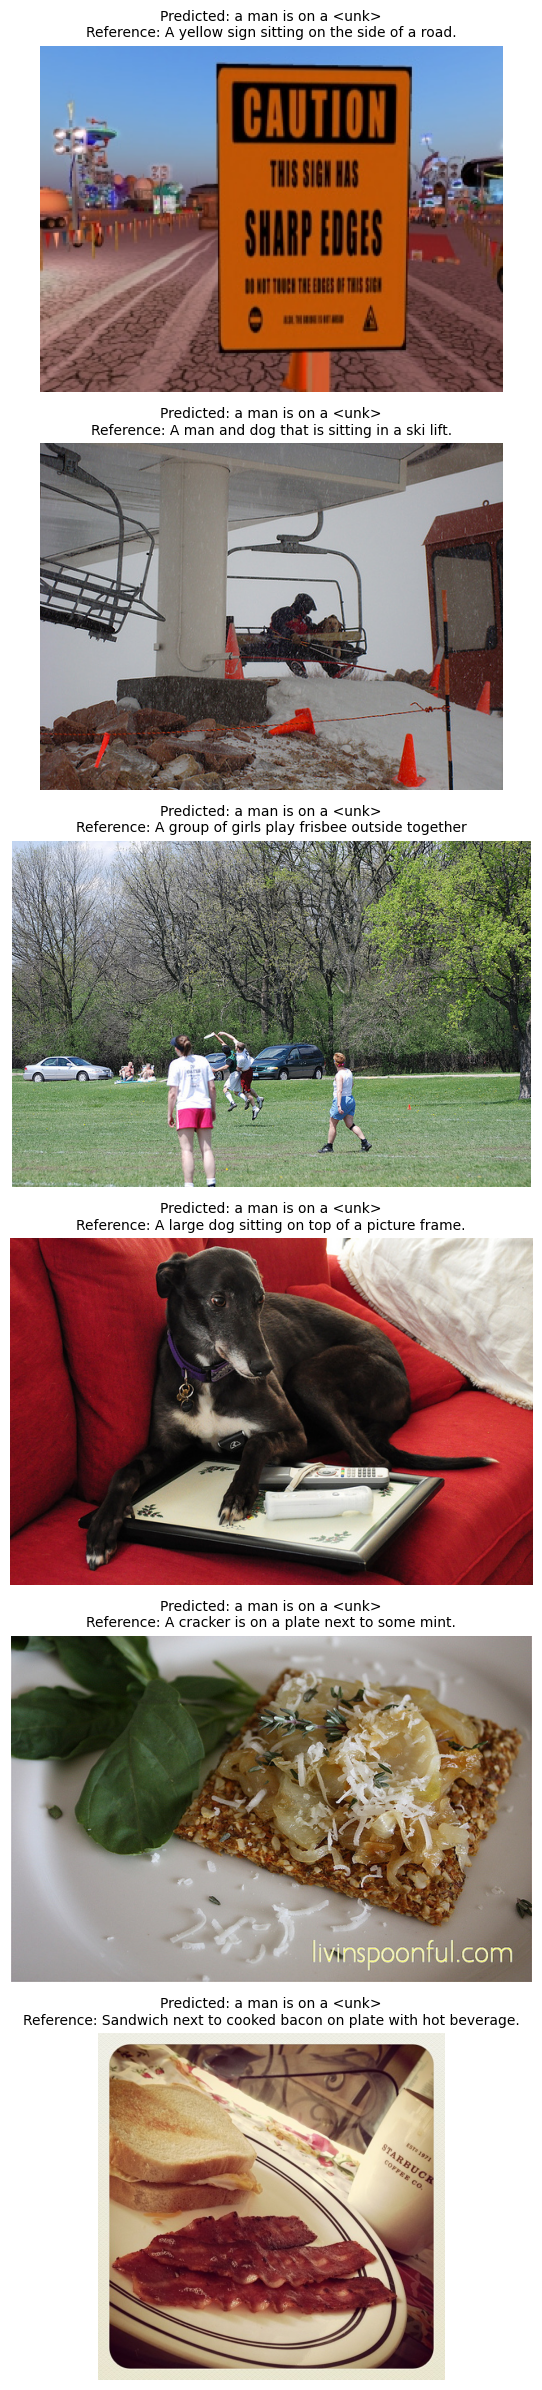

In [15]:
def show_prediction_examples(n=6):
    n = min(n, len(results_df))
    sample_rows = results_df.sample(n=n, random_state=SEED) if n > 0 else results_df
    fig, axes = plt.subplots(n, 1, figsize=(8, 4 * n))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample_rows.iterrows()):
        image = Image.open(IMAGE_DIR / row["file_name"]).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        title = f"Predicted: {row['prediction']}\nReference: {row['reference_1']}"
        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


show_prediction_examples(6)

## 9. Short Explanation for Lecturer

This project uses a simplified conditional GAN for image captioning.

**Generator:** MobileNetV2 extracts visual features from an image. An LSTM decoder receives the image feature and generates the caption word by word.

**Discriminator:** The discriminator receives two inputs: the image feature and a caption. It outputs whether the caption is a real COCO caption or a generated caption.

**Training:** First, the generator is trained using supervised cross-entropy because captions are text sequences. Then GAN fine-tuning is added. The discriminator learns to separate real and fake captions. The generator is trained with both cross-entropy loss and adversarial loss.

**Evaluation:** The notebook generates captions for validation images and calculates BLEU-1, BLEU-2, and BLEU-4. It also saves the predicted captions and metrics in the `results` folder.

**Why this version is simple:** Full GAN training for text is difficult because text tokens are discrete. This notebook uses soft word probabilities during adversarial training so gradients can flow from the discriminator back to the generator. This makes the GAN idea easier to implement and explain.